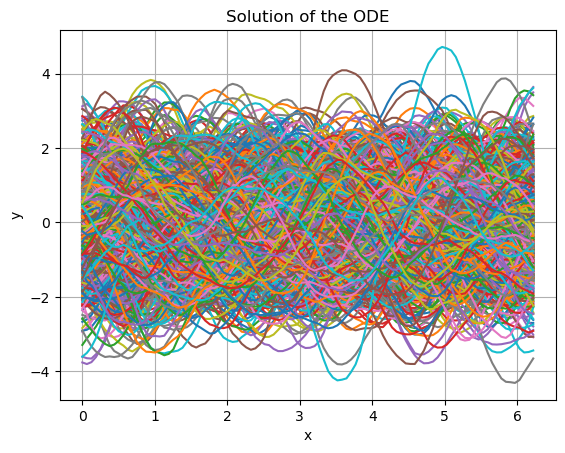

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def solve_ode(N, f):
    # Discretize the domain
    dx = 2 * np.pi / N
    x = np.linspace(0, 2 * np.pi, N, endpoint=False)

    # Setup the coefficients for the matrix
    # main_diag = (2 / dx**2 + 4) * np.ones(N)
    # off_diag = (-1 / dx**2) * np.ones(N-1)

    # Setup the coefficients for the matrix
    main_diag = (-2 / dx**2 + 4) * np.ones(N)
    off_diag = (1 / dx**2) * np.ones(N-1)

    # Create the matrix A
    A = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
    A[0, -1] = A[-1, 0] = -1 / dx**2  # Periodic boundary conditions

    # Evaluate f(x)
    b = f(x)

    # Solve the linear system
    #y = np.linalg.solve(A, b)
    y = np.linalg.inv(A).dot(b)

    return x, y

# Define the forcing function
def forcing_function(x):
    return 10*np.random.normal(size=np.size(x))
    #return np.random.normal(size=1)*np.cos(x)+np.random.normal(size=1)*np.sin(x)+10*np.random.normal(size=np.size(x))  # Example: sin(x)


y = np.zeros((1000,100)) # iteration, x
for iteration in range(1000):
    # Solve the ODE
    N = 100
    x, y[iteration,:] = solve_ode(N, forcing_function)

# Plot the results
plt.plot(x, y.T)
plt.title("Solution of the ODE")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


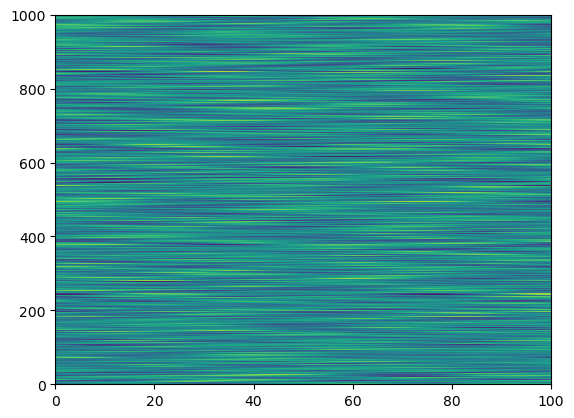

In [71]:
plt.pcolor(y)

In [72]:
#import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
principal_components = pca.fit_transform(y.T)


[0.29740947 0.25514328 0.17881803 0.16106887 0.06395446 0.01477136
 0.01325931 0.00467986 0.00318587 0.00227437]


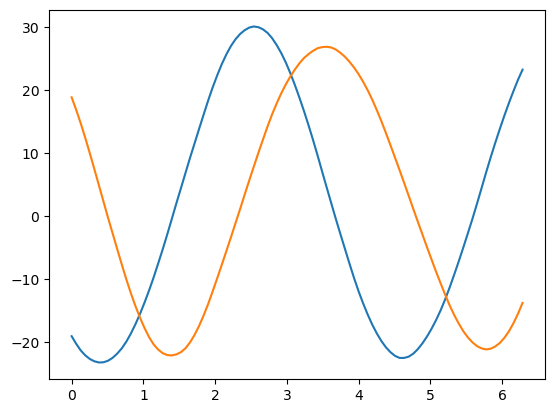

In [73]:
plt.figure()
plt.plot(np.linspace(0,2*np.pi,100),principal_components[:,0])
plt.plot(np.linspace(0,2*np.pi,100),principal_components[:,1])

explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)